In [1]:
import torch
from torchviz import make_dot
import torch.nn as nn
import torch.nn.functional as F

In [2]:
class CNN(nn.Module):
    def __init__(self) -> None:
        super().__init__()

        self.conv = nn.Sequential(
            nn.Conv2d(in_channels=1, out_channels=16, kernel_size=3, padding=1), 
            nn.ReLU(),
            nn.MaxPool2d(2), # -> (14x14)

            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)   # -> (7x7)
        )
        self.fc = nn.Linear(32 * 7 * 7, 10)

    def forward(self, x):
        x = self.conv(x)
        x = x.view(x.size(0), -1)
        x = self.fc(x)
        return x

In [3]:
class Net(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(28 * 28, 512)  # Input size is 28 * 28, output size is 512
        self.fc2 = nn.Linear(512, 10)  # Input size is 512, output size is 10

    def forward(self, x):
        x = x.view(-1, 28 * 28) # Flatten the image tensor
        x = F.relu(self.fc1(x)) # Apply ReLU activation after the first layer
        x = self.fc2(x)         # Third layer (no activation function)
        return x

[W NNPACK.cpp:53] Could not initialize NNPACK! Reason: Unsupported hardware.


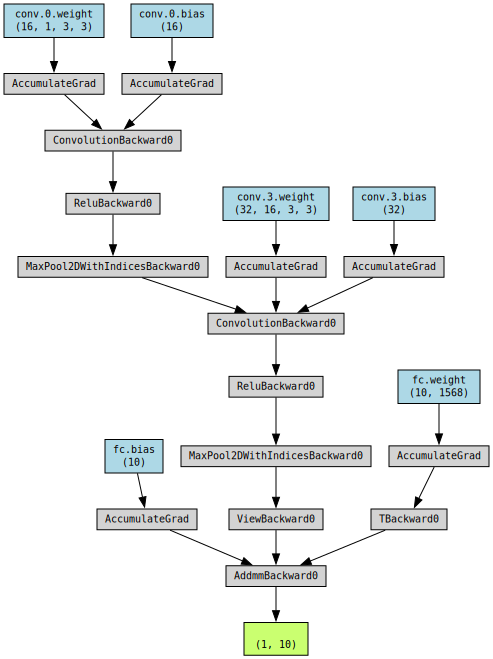

In [4]:
CNN_net = CNN()

# Use a dummy MNIST-shaped input tensor.
x = torch.randn(1, 1, 28, 28)

# Build graph from model output, not model object.
y_cnn = CNN_net(x)
dot_cnn = make_dot(y_cnn, params=dict(CNN_net.named_parameters()))
dot_cnn

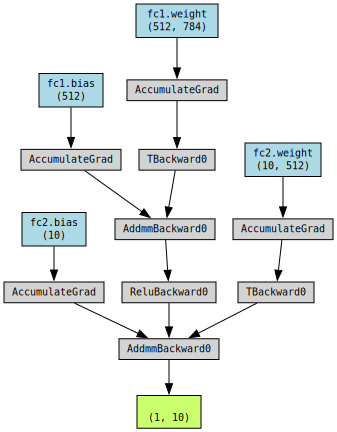

In [5]:
Net_net = Net()
y_net = Net_net(x)
dot_net = make_dot(y_net, params=dict(Net_net.named_parameters()))
dot_net

In [7]:
from torchinfo import summary
summary(CNN_net, input_size=(1, 1, 28, 28))   # batch=1

Layer (type:depth-idx)                   Output Shape              Param #
CNN                                      [1, 10]                   --
├─Sequential: 1-1                        [1, 32, 7, 7]             --
│    └─Conv2d: 2-1                       [1, 16, 28, 28]           160
│    └─ReLU: 2-2                         [1, 16, 28, 28]           --
│    └─MaxPool2d: 2-3                    [1, 16, 14, 14]           --
│    └─Conv2d: 2-4                       [1, 32, 14, 14]           4,640
│    └─ReLU: 2-5                         [1, 32, 14, 14]           --
│    └─MaxPool2d: 2-6                    [1, 32, 7, 7]             --
├─Linear: 1-2                            [1, 10]                   15,690
Total params: 20,490
Trainable params: 20,490
Non-trainable params: 0
Total mult-adds (M): 1.05
Input size (MB): 0.00
Forward/backward pass size (MB): 0.15
Params size (MB): 0.08
Estimated Total Size (MB): 0.24

In [8]:
summary(Net_net, input_size=(1, 1, 28, 28))   # batch=1

Layer (type:depth-idx)                   Output Shape              Param #
Net                                      [1, 10]                   --
├─Linear: 1-1                            [1, 512]                  401,920
├─Linear: 1-2                            [1, 10]                   5,130
Total params: 407,050
Trainable params: 407,050
Non-trainable params: 0
Total mult-adds (M): 0.41
Input size (MB): 0.00
Forward/backward pass size (MB): 0.00
Params size (MB): 1.63
Estimated Total Size (MB): 1.64